In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

```
parallel -j 8 'sh test.sh' :::: inds
~/tools/bcftools-1.17/bcftools mpileup -a AD,DP,SP -Ou -f GCF_000146045.2_R64_genomic.fna ./*_sort.bam | ~/tools/bcftools-1.17/bcftools call -f GQ,GP -mO z -o ./beer.vcf.gz
```

### Quality plot

In [31]:
qual = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_vcf.lqual',sep='\t')

In [32]:
subset_qual = qual.sample(1000000)

Text(0.5, 0, 'QUAL')

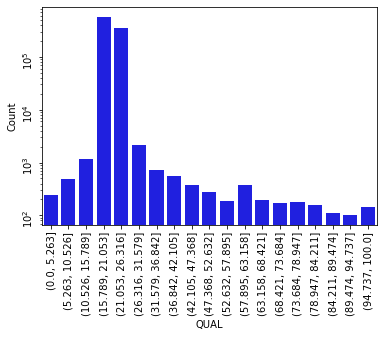

In [50]:
fig, ax = plt.subplots(figsize=(6,4))
qual_data = pd.cut(subset_qual['QUAL'], np.linspace(0, 100, 20)).value_counts().reset_index()
sns.barplot(data=qual_data, x='index', y='QUAL', color='blue')
plt.tick_params(rotation=90)
ax.set_yscale('log')
ax.set_ylabel('Count')
ax.set_xlabel('QUAL')

#### Notes
QUAL = 20

### Depth plot

In [36]:
depth = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_vcf.ldepth.mean', sep='\t')

In [51]:
subset_depth = depth.sample(1000000)

In [52]:
subset_depth.head()

,CHROM,POS,MEAN_DEPTH,VAR_DEPTH
11792843,NC_001148.4,700757,109.889,4320.52
9100080,NC_001145.3,801527,102.185,3860.30
9735174,NC_001146.8,511723,124.611,4801.86
9618503,NC_001146.8,395144,121.741,5144.20
6987223,NC_001143.9,424561,106.000,4310.15


Text(0.5, 0, 'MEAN_DEPTH')

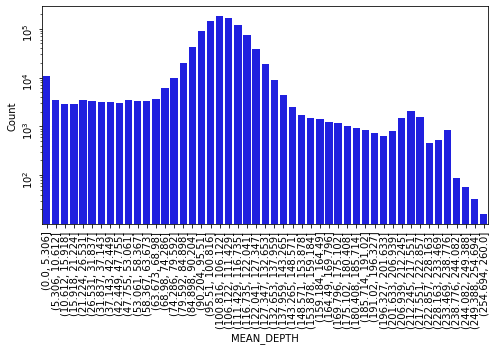

In [131]:
fig, ax = plt.subplots(figsize=(8,4))
depth_data = pd.cut(subset_depth['MEAN_DEPTH'], np.linspace(0, 260, 50)).value_counts().reset_index()
sns.barplot(data=depth_data, x='index', y='MEAN_DEPTH', color='blue')
plt.tick_params(rotation=90)
ax.set_yscale('log')
ax.set_ylabel('Count')
ax.set_xlabel('MEAN_DEPTH')

#### Notes
minimum depth 10, maximum depth 150

### Missingness
This is where it gets spicy

In [54]:
missing = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_vcf.lmiss', sep='\t')

In [55]:
subset_missing = missing.sample(1000000)

In [56]:
subset_missing.head()

,CHR,POS,N_DATA,N_GENOTYPE_FILTERED,N_MISS,F_MISS
1082492,NC_001135.5,53615,108,0,4,0.037037
2055149,NC_001136.10,710674,108,0,6,0.055556
8414907,NC_001145.3,116806,108,0,4,0.037037
5919926,NC_001142.9,102206,108,0,4,0.037037
5601387,NC_001141.2,223878,108,0,6,0.055556


Text(0.5, 0, 'F_MISS')

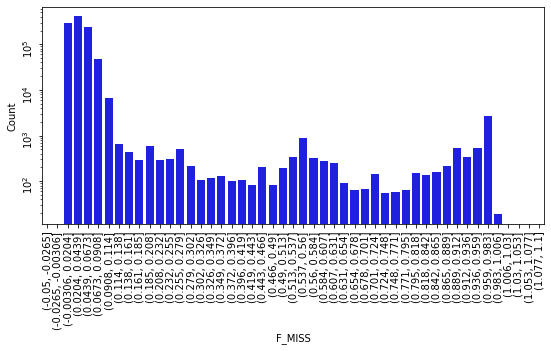

In [130]:
fig, ax = plt.subplots(figsize=(9,4))
missing_data = pd.cut(subset_missing['F_MISS'], np.linspace(-0.05, 1.1, 50)).value_counts().reset_index()
sns.barplot(data=missing_data, x='index', y='F_MISS', color='blue')
plt.tick_params(rotation=90)
ax.set_yscale('log')
ax.set_ylabel('Count')
ax.set_xlabel('F_MISS')

#### Notes
Trying missingness at 10%

### Minor allele frequency

In [90]:
maf = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_vcf.frq', sep='\t').fillna(0)

In [96]:
%%time
subset_maf = maf.sample(100000)
subset_maf['FREQ'] = subset_maf.apply(lambda row: row[['FREQ1', 'FREQ2']].min(), axis=1)

CPU times: user 1min, sys: 99 ms, total: 1min
Wall time: 1min


In [97]:
subset_maf.head()

,CHROM,POS,N_ALLELES,N_CHR,FREQ1,FREQ2,FREQ
3130045,NC_001137.3,253708,1,102,1.0,0.0,0.0
3904235,NC_001139.9,181430,1,106,1.0,0.0,0.0
11397818,NC_001148.4,308467,1,104,1.0,0.0,0.0
4240887,NC_001139.9,517925,1,108,1.0,0.0,0.0
3337048,NC_001137.3,460618,1,104,1.0,0.0,0.0


Text(0.5, 0, 'MAF')

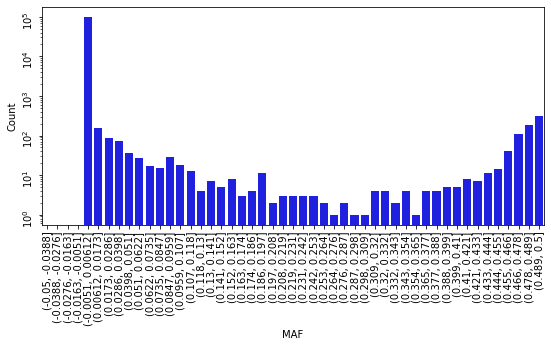

In [101]:
fig, ax = plt.subplots(figsize=(9,4))
maf_data = pd.cut(subset_maf['FREQ'], np.linspace(-0.05, 0.5, 50)).value_counts().reset_index()
sns.barplot(data=maf_data, x='index', y='FREQ', color='blue')
plt.tick_params(rotation=90)
ax.set_yscale('log')
ax.set_ylabel('Count')
ax.set_xlabel('MAF')

#### Notes
MAF of 0.10 looks ok

### Individual missingness

In [111]:
imiss = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_filtered.imiss', sep='\t').fillna(0)

In [112]:
imiss.head()

,INDV,N_DATA,N_GENOTYPES_FILTERED,N_MISS,F_MISS
0,./CommStd_S36_sort.bam,826,0,712,0.861985
1,./ExtB1_S43_sort.bam,826,0,826,1.000000
2,./HC1_S1_sort.bam,826,0,6,0.007264
3,./HI1-1_S46_sort.bam,826,0,0,0.000000
4,./HI1-3_S6_sort.bam,826,0,0,0.000000


<AxesSubplot:xlabel='F_MISS', ylabel='Count'>

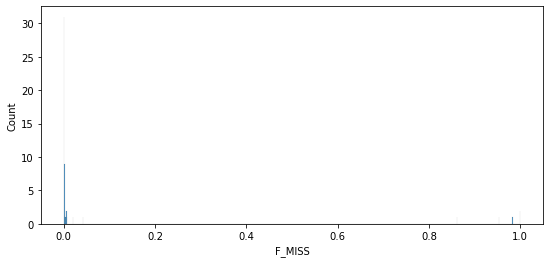

In [113]:
fig, ax = plt.subplots(figsize=(9,4))
sns.histplot(imiss['F_MISS'])

In [114]:
imiss.sort_values('F_MISS', ascending=False)

,INDV,N_DATA,N_GENOTYPES_FILTERED,N_MISS,F_MISS
27,./NTC_S54_sort.bam,826,0,826,1.000000
1,./ExtB1_S43_sort.bam,826,0,826,1.000000
29,./UC2_S23_sort.bam,826,0,812,0.983051
28,./UC1_S15_sort.bam,826,0,788,0.953995
0,./CommStd_S36_sort.bam,826,0,712,0.861985
39,./UI5-3_S21_sort.bam,826,0,35,0.042373
31,./UI1-3_S49_sort.bam,826,0,17,0.020581
2,./HC1_S1_sort.bam,826,0,6,0.007264
37,./UI4-3_S13_sort.bam,826,0,5,0.006053
11,./HI5-1_S18_sort.bam,826,0,5,0.006053


### Finalized command

`vcftools --gzvcf beer.vcf.gz --remove-indels --remove remove_ind.txt --maf 0.10 --max-missing 0.90 --minQ 20 --min-meanDP 10 --max-meanDP 150 --minDP 10 --maxDP 150 --recode --stdout | gzip -c > beer_filtered.vcf.gz`
`plink --vcf beer_filtered.vcf.gz --double-id --make-bed --out beer_filtered --allow-extra-chr`
`awk '{$1="0";print $0}' beer_filtered.bim > beer_filtered.bim.tmp`
`mv beer_filtered.bim.tmp beer_filtered.bim`
ADMIXTURE with k=2-5 according to tutorial https://speciationgenomics.github.io/ADMIXTURE/

In [124]:
nosex = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_filtered.nosex', sep='\t', header=None)

In [125]:
nosex[1] = nosex[1].apply(lambda x: x.replace('./', '').split('_')[0].split('-')[0][:2])

In [129]:
nosex.to_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_filtered.list', sep='\t', header=None, index=False)

In [128]:
nosex[1].value_counts()

HI    12
HO    12
UI    12
UO    12
Co     1
HC     1
Name: 1, dtype: int64